In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from AT_plots import create_polar_plot, cart2pola
from explorationplots import headingcalcvariations

In [2]:
seyiHeadings = pd.read_csv("testA_ant1_trajectory_filtered.csv", skiprows=2) # header=None

seyiHeadings.head()

,coords,x,y,likelihood
0,0,756.208862,2.449361,0.336535
1,1,756.234253,2.645608,0.298430
2,2,756.234253,3.266378,0.018488
3,3,756.208862,3.306514,0.020919
4,4,599.112976,73.564774,0.977934


In [3]:
usedf = seyiHeadings.copy()

print(usedf.loc[usedf.isnull().any(axis=1)])

print(usedf.isna().any().any())

Empty DataFrame
Columns: [coords, x, y, likelihood]
Index: []
False


In [6]:
antA050723 = pd.read_csv("2023-07-05_testA_ant1.csv")

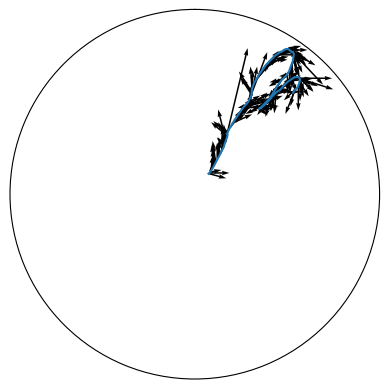

In [22]:
data = antA050723#.iloc[50:100]

_x = data['body_x']
_y = data['body_y']

r = np.hypot(_x, _y)

theta = np.arctan2(_y, _x)

U = np.append(np.diff(_y), 0)
V = np.append(np.diff(_x), 0)

fig = plt.figure()

ax = fig.add_subplot(projection='polar')

ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_ylim(600, 1000)

step = 2
ax.quiver(theta[::step], #  polar pos (x if cart)
          r[::step],     #  radius (y if cart)
          U[::step],     #  heading from pos diff
          V[::step])     #  heading from pos diff

ax.grid(False)
plt.xticks([]) 
plt.yticks([])

ax.plot(theta, r)

/its/home/nn268/antvis/antvis/optics/Captains_Log/Exp2_AntTracks/explorationplots.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  usedf['dx'] = usedf[xname].diff(periods=1) # periods = 1, take current row from following row
/its/home/nn268/antvis/antvis/optics/Captains_Log/Exp2_AntTracks/explorationplots.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  usedf['dy'] = usedf[yname].diff(periods=1)


n theta diff 50
thetafullnay [0.58729062 0.58739607 0.59462714 0.59820922 0.6008076  0.6042545
 0.60635037 0.60801647 0.60822459 0.60823446]
theta_full_seyi [        nan -0.18524782 -0.51890012 -0.26393546 -0.06257831  0.
  0.          0.18852368  0.06903536  0.75131255]
corn rel 49
corn r 49
50
rayleigh directedness res  <class 'numpy.float64'>
 circ mean std  theta -0.0
 stats nums None[0.5449243860903334]-0.0
final_headings_list_theta, final_r_list_theta [0.5449243860903334][722.914459284935]


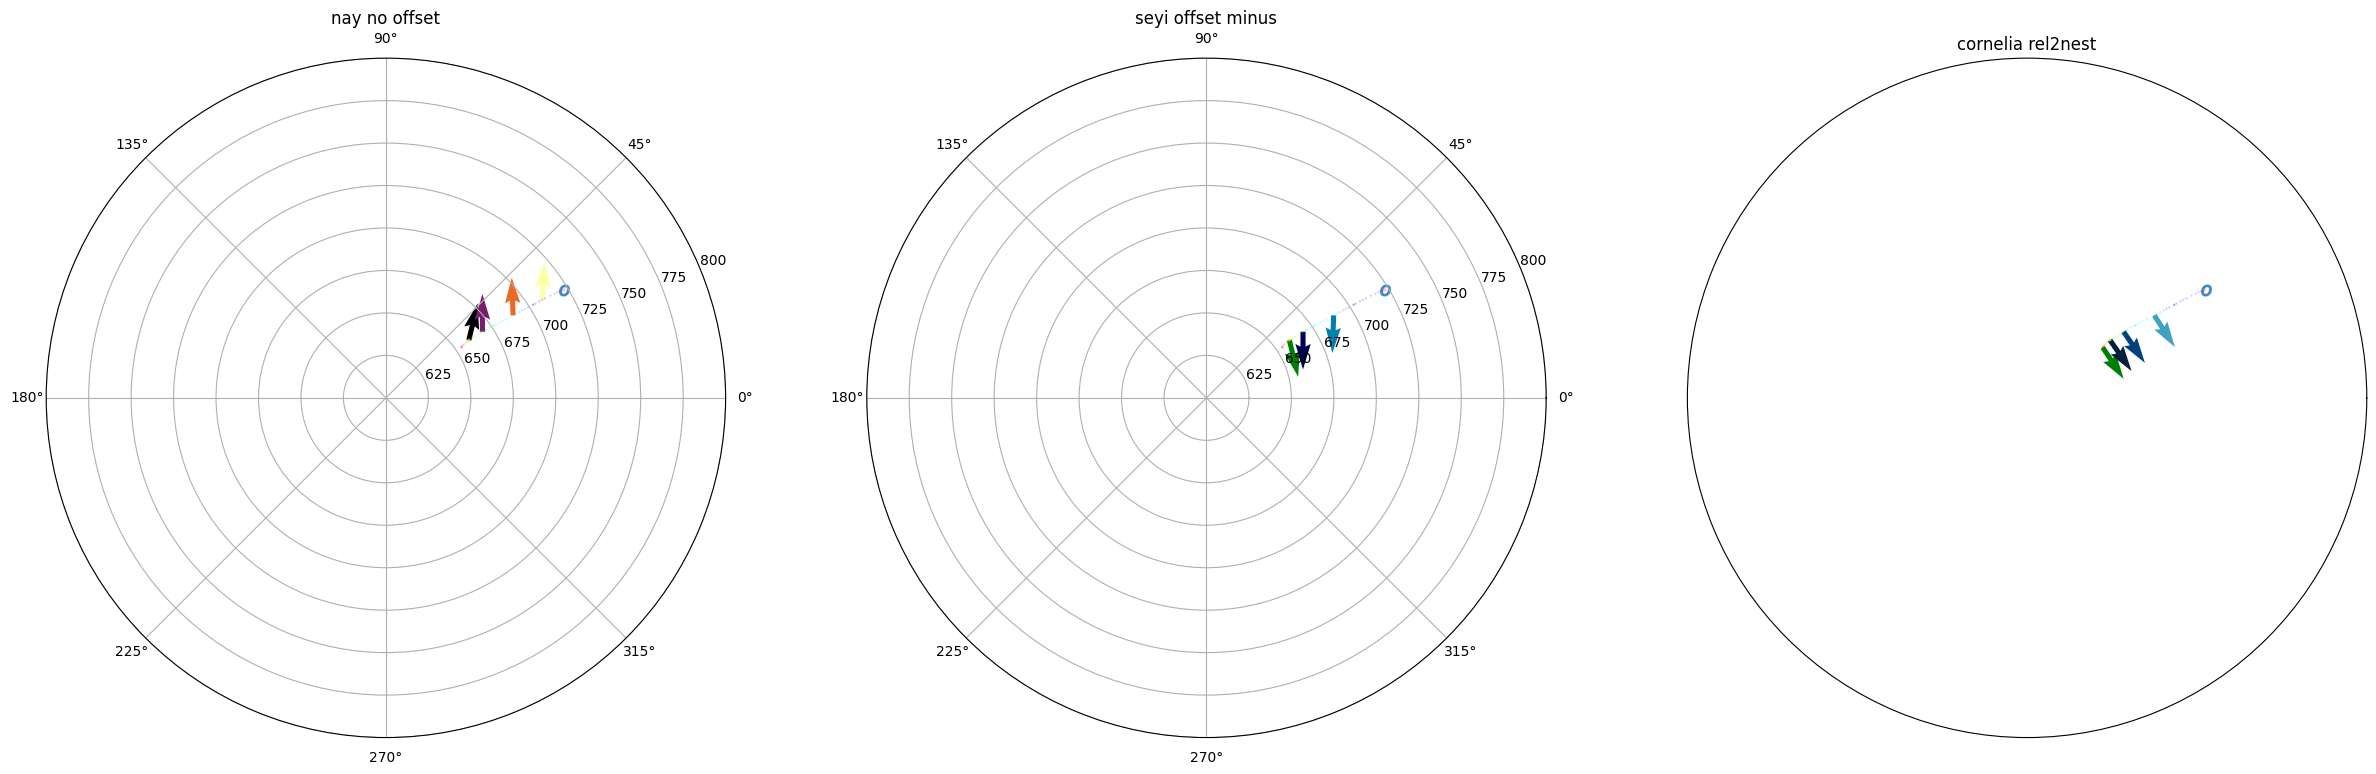

In [7]:
headingcalcvariations(antA050723.iloc[0:50], offsetval = 90, arrows=10, indexname='frame_number', xname='body_x', yname='body_y')